# GS STARR Track 1 SEMDB — Steps 01–05 + Donor Extent Analysis  *(v3)*

- Step 01: estrazione raster + clip donor I/O.
- Step 02: matching low-RAM + caliper rigidi (fail esplicito se mancanti) + SMD.
- Step 03: twin test / trend paralleli (+ flag `twin_test_compliant`).
- Step 04: Reference Area bloccata (blocca se twin non conforme).
- Step 05: Intervallo di Confidenza 90% (N effettivo) + `UNCBSL` + `BL_unadj` in tCO2e.
- **Step EXT**: Analisi Estensione Donor — confronto `5km | 10km | 20km | 30km | FULL`.

**Correzioni v3 incluse:**
- A1: SE/CI90 su **N effettivo** (pixel di riferimento unici) — anti pseudo-replicazione.
- A2: test 3× su **area** donor eleggibile vs area PA piena (non sui conteggi).
- B1: caliper obbligatori mancanti → **errore esplicito** (no skip silenzioso).
- B2: cap donor **stratificato** per texture.
- B3: footprint nativi del pixel donor propagati (`ref_cell_*`) fino a Step 04.
- B4: twin non conforme **blocca** Step 04 (override esplicito documentabile).
- B5: warning **doppio conteggio** CI/UNCBSL nel report.
- B6: conversione AGB→C (BGB via R) resa **esplicita** nel report.

**Istruzioni:** compilare solo la cella **§1 — Parametri**, poi eseguire le celle in ordine.


---
## §0. Setup ambiente


In [54]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.figsize'] = (13, 5)

from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio pyproj geopandas shapely scikit-learn scipy pyarrow -q
print('Ambiente OK')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment OK


---
## §1. Parametri

**Modificare solo questa cella.** Tutti i path e i parametri vengono
passati come argomenti espliciti alle funzioni — nessun path hardcoded nei moduli.


In [73]:
from pathlib import Path
import json, importlib.util, warnings, gc
warnings.filterwarnings('ignore')

# ── Cartelle principali ──────────────────────────────────────────────
SCRIPTS_DIR = Path('/content/drive/MyDrive/STARR_Scripts_V5')
RASTER_DIR  = Path('/content/drive/MyDrive/STARR_Idiofa_New_V2')

# ── Identificatori progetto ──────────────────────────────────────────
# RUN_ID_BASE: solo il nome base, senza path e senza suffisso _extNkm.
# Esempio: 'Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v07_raster'
# Lasciare '' per trovare tutti i TIF covariates_*.tif nella cartella.
RUN_ID_BASE  = 'Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster'
PROJECT_NAME = 'Idiofa_Lobi'

# ── Shapefile filtro spaziale (impostare None per disattivare) ────────
FNF_SHAPEFILE      = '/content/drive/MyDrive/New_Eligibility/02_Shapefile/Eligibility/FNF18_fullBuffer.shp'
ELIGIBLE_SHAPEFILE = '/content/drive/MyDrive/New_Eligibility/02_Shapefile/Eligibility/Eligible_FNF_fullBuffer.shp'

# ── Toggle eligibility donor ───────────────────────────────────
# GS non richiede eleggibilita' su TUTTA l'area del pool donor.
#   True  = applica il filtro Eligible al donor (conservativo, default)
#   False = il donor usa l'intera area non-forest (minimo GS)
USE_ELIGIBILITY = True

# ── Donor Extent ─────────────────────────────────────────────────────
# Estensione del pool donor attorno al bordo PA.
#   'full' -> nessun clip   |   5 / 10 / 20 / 30 -> buffer in km
# Impostare dopo aver letto la raccomandazione in §2b.
DONOR_EXTENT_KM = 5

# Estensioni da confrontare nell'analisi §2b (Donor Extent Analysis).
COMPARE_EXTENTS = ['full', 5, 10, 20, 30]

# ── Step 02 — parametri matching ─────────────────────────────────────
K_NEIGHBOURS         = 10
KNN_QUERY_CANDIDATES = 150
N_DONOR_SAMPLE       = 800_000
KNN_N_JOBS           = -1

# ── Step 05 — Compliant raster-based baseline / CI90 / UNCBSL ───────
RUN_STEP_05 = True

# Regola temporale metodologica.
# A T0 la baseline cumulata è zero; il primo endpoint calcolabile è T0 + 4.
T0_YEAR = 2018
MONITORING_YEAR = 2022
MIN_MONITORING_PERIOD_YEARS = 4.0
MONITORING_PERIOD_YEARS = float(MONITORING_YEAR - T0_YEAR)

if MONITORING_PERIOD_YEARS < MIN_MONITORING_PERIOD_YEARS:
    raise ValueError(
        f'Periodo non valido: {MONITORING_PERIOD_YEARS} anni. '
        f'Il minimo richiesto è T0 + {MIN_MONITORING_PERIOD_YEARS} anni.'
    )

# CI conservativo: pixel-based CI + block-based CI; usa il maggiore.
USE_CONSERVATIVE_BLOCK_CI = True
SPATIAL_BLOCK_SIZE_M = 500.0


PROJECT_AREA_HA = 15713.91

# Matched-pair rule: usa tutte le righe matchate PA-control senza deduplica.
USE_ALL_MATCHED_ROWS = True
USE_MATCHED_PROJECT_ROWS = True

# Cartella Drive dove hai salvato i raster carbon-stock / carbon-change.
CARBON_RASTER_DIR = Path('/content/drive/MyDrive/STARR_AGB_maps_GEDI_embedding')

DONOR_RASTER_SPEC = {
    'delta_raster': None,
    'stock_raster': None,
    'stock_t0_raster': str(CARBON_RASTER_DIR / f'AGB_DONOR_{T0_YEAR}_GEDI_RF.tif'),
    'stock_y_raster':  str(CARBON_RASTER_DIR / f'AGB_DONOR_{MONITORING_YEAR}_GEDI_RF.tif'),
    'stock_t0_band': 1,
    'stock_y_band': 1,
    'stock_t0_band_name': None,
    'stock_y_band_name': None,
    'units': 'AGB_Mg_ha',   # cambia in 'tC_ha' solo se i raster sono già carbonio
}

PROJECT_RASTER_SPEC = {
    'delta_raster': None,
    'stock_raster': None,
    'stock_t0_raster': str(CARBON_RASTER_DIR / f'AGB_PROJECT_{T0_YEAR}_GEDI_RF.tif'),
    'stock_y_raster':  str(CARBON_RASTER_DIR / f'AGB_PROJECT_{MONITORING_YEAR}_GEDI_RF.tif'),
    'stock_t0_band': 1,
    'stock_y_band': 1,
    'stock_t0_band_name': None,
    'stock_y_band_name': None,
    'units': 'AGB_Mg_ha',   # cambia in 'tC_ha' solo se i raster sono già carbonio
}

# ── Output (calcolato automaticamente) ───────────────────────────────
_ext_sfx    = '' if DONOR_EXTENT_KM == 'full' else f'_ext{DONOR_EXTENT_KM}km'
_run_label  = RUN_ID_BASE if RUN_ID_BASE else 'run'
OUTPUT_ROOT    = RASTER_DIR / 'STARR_outputs' / (_run_label + _ext_sfx)
COMPARISON_DIR = RASTER_DIR / 'STARR_outputs' / 'comparison'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print('SCRIPTS_DIR   :', SCRIPTS_DIR)
print('RASTER_DIR    :', RASTER_DIR)
print('RUN_ID_BASE   :', RUN_ID_BASE or '(wildcard)')
print('FNF_SHAPEFILE :', FNF_SHAPEFILE or 'OFF')
print('ELIGIBLE_SHP  :', ELIGIBLE_SHAPEFILE or 'OFF')
print('USE_ELIGIBILITY:', USE_ELIGIBILITY)
print('DONOR_EXTENT  :', DONOR_EXTENT_KM)
print('OUTPUT_ROOT   :', OUTPUT_ROOT)


SCRIPTS_DIR   : /content/drive/MyDrive/STARR_Scripts_V5
RASTER_DIR    : /content/drive/MyDrive/STARR_Idiofa_New_V2
RUN_ID_BASE   : Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster
FNF_SHAPEFILE : /content/drive/MyDrive/New_Eligibility/02_Shapefile/Eligibility/FNF18_fullBuffer.shp
ELIGIBLE_SHP  : /content/drive/MyDrive/New_Eligibility/02_Shapefile/Eligibility/Eligible_FNF_fullBuffer.shp
DONOR_EXTENT  : 5
OUTPUT_ROOT   : /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km


---
## §2. Caricamento moduli


In [74]:
def load_module(module_name, filename):
    path = SCRIPTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Script non trovato: {path}')
    spec = importlib.util.spec_from_file_location(module_name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

s01  = load_module('s01',  '01_STARR_raster_extract.py')
s02  = load_module('s02',  '02_STARR_matching_data_weights.py')
s03  = load_module('s03',  '03_STARR_twin_test_selection.py')
s04  = load_module('s04',  '04_STARR_reference_area_lock.py')
s00b = load_module('s00b', '00b_STARR_compare_extents.py')

# Step 05 — basato su raster
# Step 05 — basato su raster compliant v2 matched-row
s05 = None
for _fn05 in ['05_STARR_baseline_confidence_interval_UNCBSL_compliant_v2_matched.py',
              '05_STARR_baseline_confidence_interval_UNCBSL_compliant.py',
              '05_STARR_baseline_confidence_interval_UNCBSL.py',
              '05_STARR_baseline_confidence_interval_UNCBSL_raster_based.py']:
    if (SCRIPTS_DIR / _fn05).exists():
        s05 = load_module('s05', _fn05)
        print('Step 05 script:', _fn05)
        break
if s05 is None and RUN_STEP_05:
    print('[WARN] Script Step 05 compliant v2 non trovato — RUN_STEP_05 ignorato.')


# ── Override parametri Step 02 da §1 ─────────────────────────────────
s02.K_NEIGHBOURS         = K_NEIGHBOURS
s02.KNN_QUERY_CANDIDATES = KNN_QUERY_CANDIDATES
s02.N_DONOR_SAMPLE       = N_DONOR_SAMPLE
s02.KNN_N_JOBS           = KNN_N_JOBS

loaded = 's01 | s02 | s03 | s04 | s00b'
if s05: loaded += ' | s05'
print('Caricati:', loaded)


Step 05 script: 05_STARR_baseline_confidence_interval_UNCBSL.py
Loaded: s01 | s02 | s03 | s04 | s00b | s05


---
## §2b. Donor Extent Analysis *(opzionale)*

Esegue Step 01–04 per ogni extent in `COMPARE_EXTENTS` e determina
l'**extent minimo sufficiente** su 4 criteri:

| Criterio | Soglia |
|---|---|
| `n_donor / n_project` | ≥ 3× |
| `match_coverage_pct` | ≥ 90% |
| `twin_pass_pct` | ≥ 30% |
| `smd_max` | ≤ 0.10 |

> ⚠️ Può richiedere ore. Usare **[EXT-LOAD]** se il confronto è già stato eseguito.


In [ ]:
# ── [EXT-RUN] Esegue il confronto completo ───────────────────────────
# Commentare questa cella se si vogliono caricare risultati esistenti.

comparison_result = s00b.run_comparison(
    extents            = COMPARE_EXTENTS,
    base_dirs          = [RASTER_DIR],
    output_dir         = COMPARISON_DIR,
    run_id_base        = RUN_ID_BASE,
    fnf_shapefile      = FNF_SHAPEFILE,
    eligible_shapefile = ELIGIBLE_SHAPEFILE,
    use_eligibility    = USE_ELIGIBILITY,
    run_step_05        = False,
)
_metrics_list   = comparison_result['metrics']
_min_suff       = comparison_result['minimum_sufficient']
_recommendation = comparison_result['recommendation']
print(f'Completato: {len(_metrics_list)} extent testati')


In [ ]:
# ── [EXT-LOAD] Carica risultati già prodotti ──────────────────────────
# Alternativa a [EXT-RUN].

_summary_path = COMPARISON_DIR / 'comparison_summary.json'
if not _summary_path.exists():
    print(f'File non trovato: {_summary_path}')
    print('Eseguire prima la cella [EXT-RUN].')
else:
    with open(_summary_path) as _f:
        _comp_data = json.load(_f)
    _metrics_list   = _comp_data['metrics']
    _min_suff       = _comp_data.get('minimum_sufficient')
    _recommendation = _comp_data.get('recommendation', '')
    print(f'Caricato: {len(_metrics_list)} extent  |  {_comp_data["timestamp_utc"]}')


In [ ]:
# ── [EXT-TABLE] Tabella riepilogativa ────────────────────────────────
import pandas as pd, numpy as np

_rows = []
for _m in _metrics_list:
    if 'error' in _m:
        _rows.append({'Extent': str(_m['extent_km']), 'ERRORE': _m['error']})
        continue
    _c = _m['criteria']
    _ratio_lbl = f"{_m['ratio_donor_project']:.1f}x"
    if _m.get('ratio_is_area_based'):
        _ratio_lbl += ' (area)'
    _rows.append({
        'Extent':     'FULL' if _m['extent_km'] == 'full' else f"{_m['extent_km']}km",
        'n_donor':    f"{_m['n_donor']:,}",
        'ratio':      _ratio_lbl,
        'match%':     f"{_m['match_coverage_pct']:.1f}%",
        'twin%':      f"{_m['twin_pass_pct']:.1f}%",
        'SMD_max':    f"{_m['smd_max']:.3f}" if _m.get('smd_max') is not None else 'N/A',
        'ref_ha':     _m.get('reference_area_ha', '-'),
        'ratio>=3x':  'OK' if _c.get('ratio_3x')        else '--',
        'match>=90%': 'OK' if _c.get('match_cov_90pct') else '--',
        'twin>=30%':  'OK' if _c.get('twin_pass_30pct') else '--',
        'twin_conf':  'OK' if _c.get('twin_compliant')  else '--',
        'SMD<=0.10':  'OK' if _c.get('smd_le_010')      else '--',
        'ALL OK':     'SI' if _c.get('ALL_SUFFICIENT')   else 'no',
    })

def _color(val):
    if str(val) in ('OK', 'SI'):  return 'background-color:#c8e6c9;color:#1b5e20'
    if str(val) in ('--', 'no'): return 'background-color:#ffcdd2;color:#b71c1c'
    return ''

_bool_cols = ['ratio>=3x', 'match>=90%', 'twin>=30%', 'twin_conf', 'SMD<=0.10', 'ALL OK']
display(pd.DataFrame(_rows).style
        .applymap(_color, subset=_bool_cols)
        .set_caption('GS STARR — Donor Extent Comparison (v3: ratio su AREA, twin_conf)'))


In [ ]:
# ── [EXT-PLOT] Plot comparativo 4-panel + heatmap ────────────────────
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

_valid  = [_m for _m in _metrics_list if 'error' not in _m]
_labels = ['FULL' if _m['extent_km'] == 'full' else f"{_m['extent_km']}km" for _m in _valid]
_x      = np.arange(len(_labels))
_bkw    = dict(width=0.55, edgecolor='white', zorder=3)
_gc     = lambda ok: '#2e7d32' if ok else '#c62828'

_fig = plt.figure(figsize=(max(16, len(_labels)*3.2), 14), facecolor='white')
_gs  = GridSpec(2, 4, figure=_fig, hspace=0.55, wspace=0.38, height_ratios=[2.5, 1])

for _i, (_key, _title, _thresh, _crit, _better) in enumerate([
    ('ratio_donor_project', 'A — Donor/Project ratio (>=3x)', 3.0,  'ratio_3x',        'high'),
    ('match_coverage_pct',  'B — Match coverage % (>=90)',    90.0, 'match_cov_90pct', 'high'),
    ('twin_pass_pct',       'C — Twin pass % (>=30)',         30.0, 'twin_pass_30pct', 'high'),
    ('smd_max',             'D — SMD max (<=0.10)',           0.10, 'smd_le_010',      'low'),
]):
    _ax   = _fig.add_subplot(_gs[0, _i])
    _vals = [float(_m.get(_key) or 0) for _m in _valid]
    _cols = [_gc(_m['criteria'].get(_crit, False)) for _m in _valid]
    _ax.bar(_x, _vals, color=_cols, alpha=0.82, **_bkw)
    _ax.axhline(_thresh, color='#f5a623', ls='--', lw=1.6, label=f'Soglia {_thresh}')
    _ax.set_xticks(_x); _ax.set_xticklabels(_labels, fontsize=8)
    _ax.set_title(_title, fontsize=9, fontweight='bold')
    _ax.legend(fontsize=7); _ax.grid(axis='y', alpha=0.3, zorder=0)
    for _xi, _vi in zip(_x, _vals):
        _ax.text(_xi, _vi, f'{_vi:.2f}', ha='center', va='bottom', fontsize=7)

_ax2   = _fig.add_subplot(_gs[1, :])
_ckeys = ['ratio_3x', 'match_cov_90pct', 'twin_pass_30pct', 'smd_le_010', 'ALL_SUFFICIENT']
_clbls = ['Ratio>=3x', 'Match>=90%', 'Twin>=30%', 'SMD<=0.10', 'TUTTO OK']
_heat  = np.array([[1. if _m['criteria'].get(_k) else 0. for _m in _valid] for _k in _ckeys])
_ax2.imshow(_heat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
_ax2.set_xticks(range(len(_valid)));  _ax2.set_xticklabels(_labels, fontsize=9)
_ax2.set_yticks(range(len(_ckeys))); _ax2.set_yticklabels(_clbls, fontsize=9)
for _i in range(len(_ckeys)):
    for _j in range(len(_valid)):
        _ax2.text(_j, _i, 'OK' if _heat[_i, _j] else '--',
                  ha='center', va='center', fontsize=10,
                  color='white' if _heat[_i, _j] == 0 else '#1b5e20', fontweight='bold')
if _min_suff:
    _ml = 'FULL' if _min_suff['extent_km'] == 'full' else f"{_min_suff['extent_km']}km"
    if _ml in _labels:
        _j0 = _labels.index(_ml)
        for _ii in range(len(_ckeys)):
            _ax2.add_patch(plt.Rectangle((_j0-.5, _ii-.5), 1, 1,
                           fill=False, edgecolor='#0d47a1', lw=3))
_ax2.set_title('Heatmap criteri (bordo blu = extent minimo sufficiente)', fontsize=9, fontweight='bold')
_fig.suptitle('GS STARR — Donor Extent Comparison', fontsize=11, fontweight='bold')
plt.tight_layout()
_fig.savefig(COMPARISON_DIR / 'comparison_plots_notebook.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# ── [EXT-TREND] Andamento metriche vs distanza ───────────────────────
_num  = [_m for _m in _valid if _m['extent_km'] != 'full']
_full = [_m for _m in _valid if _m['extent_km'] == 'full']

if _num:
    _xs = [float(_m['extent_km']) for _m in _num]
    _fig2, _axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
    for _key, _title, _thresh, _ax in [
        ('match_coverage_pct', 'Match coverage %', 90.0, _axes[0]),
        ('twin_pass_pct',      'Twin pass %',       30.0, _axes[1]),
        ('smd_max',            'SMD max',            0.10, _axes[2]),
    ]:
        _ys = [float(_m.get(_key) or 0) for _m in _num]
        _ax.plot(_xs, _ys, 'o-', lw=2, ms=8, color='#1565c0', zorder=3)
        _ax.axhline(_thresh, color='#f5a623', ls='--', lw=1.5, label=f'Soglia {_thresh}')
        if _full:
            _fy = float(_full[0].get(_key) or 0)
            _ax.axhline(_fy, color='#7b1fa2', ls=':', lw=1.5, label=f'FULL={_fy:.2f}')
        _ax.set_xlabel('Buffer donor (km)', fontsize=9)
        _ax.set_title(_title, fontsize=9, fontweight='bold')
        _ax.legend(fontsize=7); _ax.grid(alpha=0.3)
    _fig2.suptitle('Andamento metriche vs extent donor', fontsize=10, fontweight='bold')
    plt.tight_layout()
    _fig2.savefig(COMPARISON_DIR / 'metrics_vs_extent.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


In [ ]:
# ── [EXT-DECISION] Raccomandazione ───────────────────────────────────
print('=' * 65)
print('RACCOMANDAZIONE DONOR EXTENT')
print('=' * 65)
print(_recommendation)
print()
if _min_suff:
    _rec_ext = _min_suff['extent_km']
    print(f'-> Impostare in §1:  DONOR_EXTENT_KM = {repr(_rec_ext)}')
    print(f"   n_donor        : {_min_suff['n_donor']:,}")
    print(f"   ratio          : {_min_suff['ratio_donor_project']:.1f}x")
    print(f"   match_coverage : {_min_suff['match_coverage_pct']:.1f}%")
    print(f"   twin_pass      : {_min_suff['twin_pass_pct']:.1f}%")
    print(f"   smd_max        : {_min_suff['smd_max']:.3f}")
    print(f"   reference_area : {_min_suff.get('reference_area_ha', 'N/A')} ha")
else:
    print('Nessun extent soddisfa tutti i criteri.')
    print('Aggiungere estensioni maggiori a COMPARE_EXTENTS e rieseguire [EXT-RUN].')
print('=' * 65)


---
## §3. Step 01 — Estrazione raster

`DONOR_EXTENT_KM`, `RUN_ID_BASE`, `FNF_SHAPEFILE` e `ELIGIBLE_SHAPEFILE`
vengono passati come argomenti — nessun path hardcoded nel modulo.


In [4]:
proj_df, donor_df, meta, out01 = s01.run_extraction(
    base_dirs          = [RASTER_DIR],
    donor_extent_km    = DONOR_EXTENT_KM,
    run_id_base        = RUN_ID_BASE,
    fnf_shapefile      = FNF_SHAPEFILE,
    eligible_shapefile = ELIGIBLE_SHAPEFILE,
    use_eligibility    = USE_ELIGIBILITY,
    verbose            = True,
)

# OUTPUT_ROOT si aggiorna con il run_id effettivo prodotto da Step 01
OUTPUT_ROOT = out01.parent

print('Step 01 output   :', out01)
print('Pixel progetto   :', f'{len(proj_df):,}')
print('Pixel donor      :', f'{len(donor_df):,}')
print('Ratio donor/proj :', f'{len(donor_df)/max(1,len(proj_df)):.1f}x')
print('Anno T0          :', meta.get('t0_year'))
print('Anni NDVI        :', meta.get('year_list'))
print('Covariate        :', meta.get('continuous_covariates'))
print('Estensione donor :', meta.get('donor_extent_label', 'FULL'))



STEP 01 | Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km
Donor extent       : 5km
FNF shapefile      : FNF18_fullBuffer.shp
Eligible shapefile : Eligible_FNF_fullBuffer.shp
Output: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km/01_extract

[1] Ricerca tiles...
    Project: 1 tile trovate
      covariates_project_Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster.tif
    Donor: 1 tile trovate
      covariates_donor_Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster.tif

[2] Estrazione PROJECT...
    [GC] [START] RAM prima project | RAM: 283 MB
    CRS: EPSG:32734 | pixel: 30.0 m
    covariates_project_Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster.tif
      1479x1993px | EPSG:32734 | 17 bande
      Origin: (305220.00, 9465630.00) | Pixel: 30.0m
    [GC] blocchi covariates_project_Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster.tif (181,407 px) | RAM: 571 MB
      -> 181,407 px (1.9s)
    [GC] tile concat Project 

---
## §4. Step 02 — Matching low-RAM + SMD

`donor_df=None` — il donor viene riletto in streaming dal parquet di Step 01,
senza tenerlo in RAM. I parametri KNN sono già stati impostati in §2.



STEP 02 — Matching | K=10 | candidates=150 | N_donor=800,000
Output: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km/02_matching
    Trovato: donor_pixels_raw.parquet
    Covariate Mahalanobis: ['NDVI_t0', 'NDVI_slope_5yr', 'elevation', 'slope_deg', 'precip_mm_yr', 'SOC_g_kg', 'dist_roads_km']
    NDVI annuali: ['NDVI_2013', 'NDVI_2014', 'NDVI_2015', 'NDVI_2016', 'NDVI_2017']

[1] Texture WRB...
    WRB filter: 176,931 → 176,931 px validi
    WRB filter: 1,960,860 → 1,960,860 px validi
    Project: 176,931 | Donor: 1,960,860

[2] Prefilter donor (loose)...
    Prefilter NDVI_t0           : [0.241, 0.798] 1,960,860 → 1,941,844
    Prefilter NDVI_slope_5yr    : [-0.035, 0.099] 1,941,844 → 1,939,105
    Prefilter elevation         : [468.000, 776.000] 1,939,105 → 1,819,255
    Prefilter slope_deg         : [-4.467, 26.805] 1,819,255 → 1,810,563
    Prefilter precip_mm_yr      : [1590.600, 1670.400] 1,810,563 → 1,781,909
   

,SMD,proj_mean,ref_mean,passed
covariate,,,,
NDVI_t0,0.0196,0.527150,0.528779,True
NDVI_slope_5yr,0.0175,0.033720,0.033377,True
elevation,0.0294,662.768396,664.269648,True
slope_deg,0.0182,5.311489,5.229898,True
precip_mm_yr,0.0064,1644.998384,1645.076862,True
SOC_g_kg,0.0326,39.029384,38.788854,True
dist_roads_km,0.0032,1.262017,1.258864,True


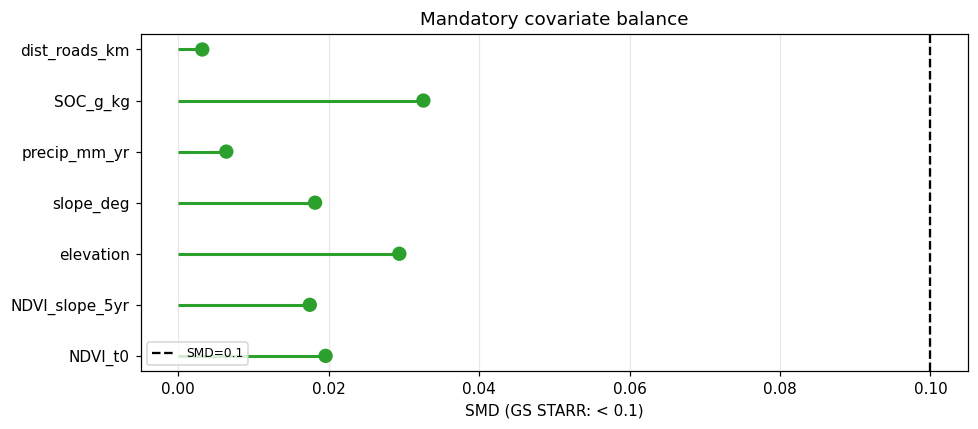

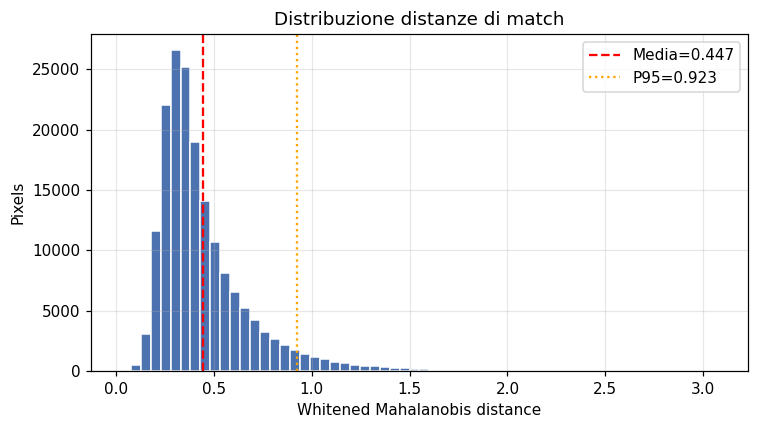

In [5]:
# donor_df non serve in RAM dopo Step 01: Step 02 rilegge il parquet da disco
# (caricamento completo + cap STRATIFICATO per texture; NON è streaming a batch).
del donor_df; gc.collect()

matched_df, weights_dict, imp_df, smd_df, figs02, out02 = s02.run_matching_step(
    base_dirs  = [out01],
    output_dir = OUTPUT_ROOT / '02_matching',
    proj_df    = proj_df,
    donor_df   = None,
    meta       = meta,
    verbose    = True,
)
print('Step 02 output:', out02)
print('Righe matchate:', f'{len(matched_df):,}')
print('SMD max       :', round(smd_df['SMD'].max(), 4) if not smd_df.empty else 'N/A')
display(smd_df)


---
## §5. Step 03 — Twin test / Trend paralleli


In [ ]:
all_pairs, twin_pixels, twin_report, figs03, out03 = s03.run_twin_test(
    base_dirs  = [out02],
    output_dir = OUTPUT_ROOT / '03_twin_test',
    matched_df = matched_df,
    proj_df    = proj_df,
    meta       = meta,
    verbose    = True,
)
print('Step 03 output     :', out03)
print('Pixel twin-testati :', f'{len(twin_pixels):,}')
print('Aggregato superato :', twin_report.get('aggregate_twin_passed'))
print(json.dumps(twin_report, indent=2)[:4000])


---
## §6. Step 04 — Reference Area bloccata


In [ ]:
del proj_df; gc.collect()

bounds_gdf, mon_gdf, fig04, out04, manifest = s04.run_reference_area_lock(
    base_dirs   = [out03],
    output_dir  = OUTPUT_ROOT / '04_reference_area',
    passed_df   = twin_pixels,
    meta        = meta,
    twin_report = twin_report,
    verbose     = True,
)
print('Step 04 output    :', out04)
print('Feature RA        :', len(bounds_gdf))
print('Punti monitoraggio:', len(mon_gdf))
_ra = manifest.get('reference_area_definition', {})
print('Reference area ha :', _ra.get('total_ha'))
print('Stato lock        :', manifest.get('lock_status'))
print(json.dumps(manifest, indent=2)[:4000])


---
## §7. Step 05 — Baseline 90% CI / UNCBSL *(opzionale)*

Eseguire solo quando disponibili i dati carbon-stock-change dei pixel controllo bloccati.
File accettato: `control_carbon_stock_change.parquet` o `.csv` in `OUTPUT_ROOT`.
Impostare `RUN_STEP_05 = True` in §1 per abilitare.


PROJECT_AREA_HA resolved: 15713.91 ha
PROJECT_AREA source     : notebook variable PROJECT_AREA_HA

STEP 05 — Raster-based Unadjusted Baseline + CI90 / UNCBSL
RUN root                  : /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km
Twin pixels source         : provided_dataframe
Project pixels source      : matched_project_rows_from_twin_df
T0 year                    : 2018
Monitoring year            : 2022
Monitoring period          : 4 years
First valid endpoint       : 2022
Output                     : /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km/05_baseline_CI_UNCBSL_Embeddings_GEDI_2024

[1] Locked controls: 70,000 rows -> 70,000 matched rows (all_matched_rows_no_deduplication)
[2] Project pixels : 70,000 rows -> 70,000 matched rows (all_matched_rows_no_deduplication)

STEP 05 RESULTS
────────────────────────────────────────────────────────────────

,NDVI_t0,NDVI_slope_5yr,ref_NDVI_2013,ref_NDVI_2014,ref_NDVI_2015,ref_NDVI_2016,ref_NDVI_2017,elevation,slope_deg,precip_mm_yr,...,_ref_lon_key,_ref_lat_key,ref_stock_t0_raw,ref_stock_y_raw,ref_C_t0_tC_ha,ref_C_y_tC_ha,ref_deltaC_tC_ha_yr,_ci_block_x,_ci_block_y,_ci_block_id
0,0.590250,0.044431,0.453654,0.670736,0.444725,0.653873,0.684240,647.0,3.819289,1651.0,...,19.445412,-4.859664,18.233503,18.579136,11.997645,12.225071,0.056857,655.0,18925.0,655_18925
1,0.639043,0.031438,0.442603,0.716208,0.282331,0.521165,0.697315,662.0,2.931464,1659.0,...,19.406836,-4.816709,16.155119,10.188373,10.630068,6.703949,-0.981530,646.0,18934.0,646_18934
2,0.613954,0.042736,0.274141,0.705494,0.330815,0.443523,0.618805,675.0,0.000000,1658.0,...,19.397340,-4.829709,16.637980,10.701664,10.947791,7.041695,-0.976524,644.0,18931.0,644_18931
3,0.561749,0.019609,0.368998,0.687558,0.443868,0.493586,0.564031,663.0,2.079020,1658.0,...,19.406994,-4.864729,15.329056,20.191000,10.086519,13.285678,0.799790,646.0,18924.0,646_18924
4,0.569841,0.026931,0.497535,0.718521,0.458375,0.570611,0.706144,668.0,1.860984,1657.0,...,19.396217,-4.846798,15.120063,16.940603,9.949001,11.146917,0.299479,644.0,18928.0,644_18928


,NDVI_t0,NDVI_slope_5yr,ref_NDVI_2013,ref_NDVI_2014,ref_NDVI_2015,ref_NDVI_2016,ref_NDVI_2017,elevation,slope_deg,precip_mm_yr,...,ols_valid,twin_pass,_proj_lon_key,_proj_lat_key,proj_stock_t0_raw,proj_stock_y_raw,proj_C_t0_tC_ha,proj_C_y_tC_ha,proj_deltaC_tC_ha_yr,project_pixel_area_ha
0,0.590250,0.044431,0.453654,0.670736,0.444725,0.653873,0.684240,647.0,3.819289,1651.0,...,True,True,19.593192,-4.833716,26.278925,28.674316,17.291533,18.867700,0.394042,0.228929
1,0.639043,0.031438,0.442603,0.716208,0.282331,0.521165,0.697315,662.0,2.931464,1659.0,...,True,True,19.593463,-4.833717,53.811008,55.642822,35.407644,36.612977,0.301333,0.228929
4,0.569841,0.026931,0.497535,0.718521,0.458375,0.570611,0.706144,668.0,1.860984,1657.0,...,True,True,19.585077,-4.833971,12.417354,15.398281,8.170619,10.132069,0.490363,0.228929
5,0.584539,0.035598,0.221630,0.738011,0.425498,0.552058,0.492597,675.0,0.927410,1658.0,...,True,True,19.593462,-4.833988,22.942617,26.741325,15.096242,17.595792,0.624887,0.228929
6,0.513658,0.032263,0.505083,0.629854,0.438304,0.638701,0.661975,666.0,0.927410,1660.0,...,True,True,19.578044,-4.834227,8.976476,10.277407,5.906521,6.762534,0.214003,0.228929


,run_id,project_name,timestamp_utc,methodology,step,n_rows_control_before_deduplication,n_rows_project_before_deduplication,row_selection_mode,control_row_selection_mode,project_row_selection_mode,...,t0_year,monitoring_year,minimum_monitoring_period_years,first_valid_monitoring_year,t0_cumulative_unadjusted_baseline_tC,t0_ci90_abs_tC,t0_uncbsl_status,note,coordinate_key_round_decimals,area_metadata
0,Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_rast...,Idiofa_Lobi,2026-06-03T13:08:01.599093+00:00,GS STARR Track 1 SEMDB,05_raster_based_unadjusted_baseline_CI90_UNCBSL,70000,70000,all_matched_rows_no_deduplication,all_matched_rows_no_deduplication,all_matched_rows_no_deduplication,...,2018,2022,4.0,2022,0.0,0.0,not_applicable_at_T0_by_definition,This is the unadjusted baseline plus baseline ...,7,"{'area_source': 'argument:project_area_ha', 'p..."



TEMPORAL RULE
  T0 year                    : 2018
  monitoring year            : 2022
  first valid monitoring year: 2022
  baseline at T0             : 0.0

MATCHED ROWS / N EFFETTIVO (A1)
  control matched valid rows : 69784
  unique ref represented     : 46791
  N effettivo per SE         : 46791
  project matched valid rows : 68641
  unique PA represented      : 68641
  project area used ha       : 15713.91

UNADJUSTED BASELINE  (BL_unadj,y = ΔC_ref,y × A_project, Eq-31a)
  ΔC_ref,y creditable        : +0.042164 tC/ha/yr
  raw mean tC/ha/yr          : 0.042163786230014974
  creditable total tC/year   : 662.5579420776946
  creditable total tC/period : 2650.2317683107785
  >> BL_unadj,y  tCO2e/yr    : +2,429.3791
  >> BL_unadj    tCO2e/period: +9,717.5165   (valore PM)

CONFIDENCE INTERVAL / UNCBSL
  CI90 pixel (N eff) tC/ha/yr: 0.006954804250746102
  CI90 pixel naive (diag)    : 0.005694926778555141
  CI90 block tC/ha/yr        : 0.01913109261961001
  CI90 final tC/ha/yr        : 0

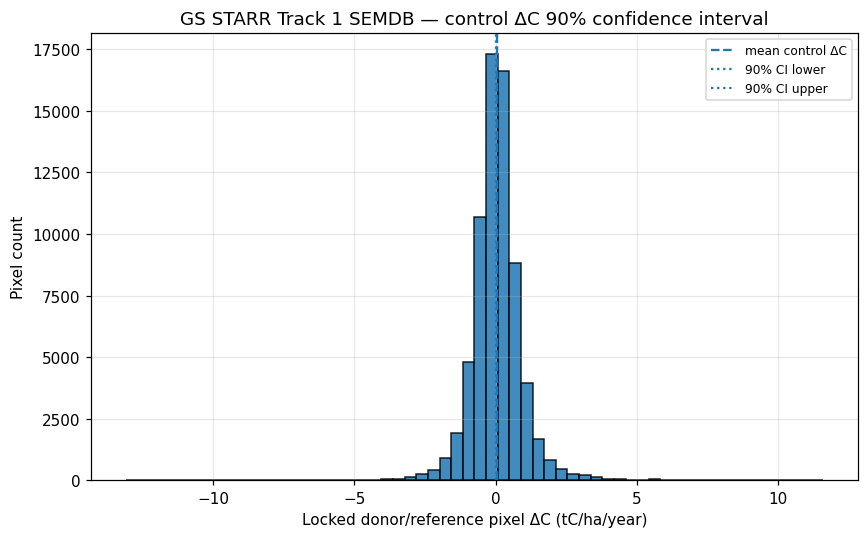

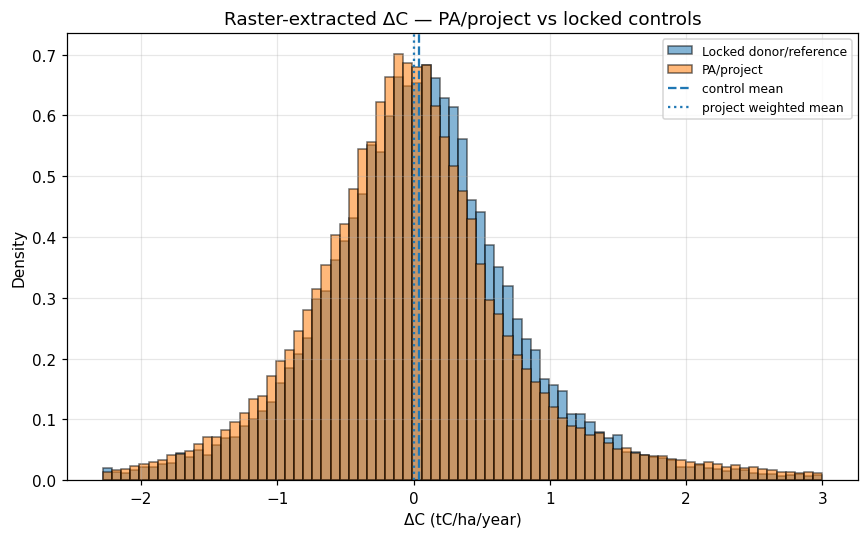

In [75]:
if not RUN_STEP_05:
    print('Step 05 saltato (RUN_STEP_05=False in §1).')
elif s05 is None:
    print('[ERR] Script Step 05 non trovato in SCRIPTS_DIR.')
else:
    import pandas as pd
    import json

    def _as_positive_float(v):
        try:
            x = float(v)
            return x if x > 0 else None
        except Exception:
            return None

    def _find_area_in_obj(obj, path=''):
        """Cerca ricorsivamente un campo area nei dati upstream."""
        keys = {
            'project_area_ha', 'pa_area_ha', 'activity_area_ha',
            'project_valid_area_ha', 'project_total_area_ha',
            'valid_project_area_ha', 'total_project_area_ha',
            'project_area', 'pa_area',
        }
        if isinstance(obj, dict):
            for k, v in obj.items():
                lk = str(k).lower()
                if lk in keys:
                    x = _as_positive_float(v)
                    if x is not None:
                        return x, f'{path}.{k}' if path else str(k)
                found = _find_area_in_obj(v, f'{path}.{k}' if path else str(k))
                if found[0] is not None:
                    return found
        elif isinstance(obj, (list, tuple)):
            for i, v in enumerate(obj):
                found = _find_area_in_obj(v, f'{path}[{i}]')
                if found[0] is not None:
                    return found
        return None, None

    def resolve_project_area_for_step05():
        """
        Risolve la PA area completa senza hardcoding nello script.
        Priorità:
          1. PROJECT_AREA_HA se impostata nel notebook (>0)
          2. variabili comuni dei primi dati: PROJECT_VALID_AREA_HA, PA_AREA_HA, ACTIVITY_AREA_HA...
          3. dizionari upstream: meta, manifest, twin_report, weights_dict, comparison_result
          4. JSON in OUTPUT_ROOT/01_extract se contiene un campo area esplicito
        """
        # 1) valore esplicito nella cella parametri o in una cella precedente
        for name in [
            'PROJECT_AREA_HA', 'PROJECT_VALID_AREA_HA', 'PA_AREA_HA',
            'ACTIVITY_AREA_HA', 'TOTAL_PROJECT_AREA_HA', 'VALID_PROJECT_AREA_HA'
        ]:
            if name in globals():
                x = _as_positive_float(globals()[name])
                if x is not None:
                    return x, f'notebook variable {name}'

        # 2) dizionari upstream già prodotti dagli step precedenti
        for name in ['meta', 'manifest', 'twin_report', 'weights_dict', 'comparison_result', '_min_suff']:
            if name in globals():
                x, src = _find_area_in_obj(globals()[name], name)
                if x is not None:
                    return x, src

        # 3) report JSON precedenti, solo se contengono un campo area esplicito
        for p in [
            OUTPUT_ROOT / '01_extract' / 'extraction_report.json',
            OUTPUT_ROOT / '04_reference_area' / 'reference_area_FINAL_manifest.json',
        ]:
            if p.exists():
                with open(p) as f:
                    data = json.load(f)
                x, src = _find_area_in_obj(data, str(p.name))
                if x is not None:
                    return x, str(p) + ' :: ' + src

        raise ValueError(
            'Impossibile risolvere PROJECT_AREA_HA. Imposta prima una variabile notebook, per esempio:\n'
            '    PROJECT_VALID_AREA_HA = 15315.22\n'
            'oppure fai esportare/leggere questo valore nei primi dati upstream. '
            'Step 05 non userà la somma delle matched rows come area PA.'
        )

    PROJECT_AREA_HA_RESOLVED, PROJECT_AREA_SOURCE = resolve_project_area_for_step05()
    print('PROJECT_AREA_HA risolta:', PROJECT_AREA_HA_RESOLVED, 'ha')
    print('PROJECT_AREA sorgente   :', PROJECT_AREA_SOURCE)

    control_pixels, project_pixels, ci_summary, ci_report, figs05, out05 = (
        s05.run_baseline_ci_uncbsl_from_rasters(
            base_dirs                    = [OUTPUT_ROOT],
            output_dir                   = OUTPUT_ROOT / '05_baseline_CI_UNCBSL_Embeddings_GEDI_2024',
            donor_raster_spec            = DONOR_RASTER_SPEC,
            project_raster_spec          = PROJECT_RASTER_SPEC,
            twin_df                      = twin_pixels,
            project_df                   = None,  # None => usa proj_lon/proj_lat da twin_pixels matchati
            project_area_ha              = PROJECT_AREA_HA_RESOLVED,
            use_all_matched_rows         = USE_ALL_MATCHED_ROWS,
            use_matched_project_rows     = USE_MATCHED_PROJECT_ROWS,

            monitoring_period_years      = MONITORING_PERIOD_YEARS,
            t0_year                      = T0_YEAR,
            monitoring_year              = MONITORING_YEAR,
            min_monitoring_period_years  = MIN_MONITORING_PERIOD_YEARS,
            use_conservative_block_ci    = USE_CONSERVATIVE_BLOCK_CI,
            spatial_block_size_m         = SPATIAL_BLOCK_SIZE_M,
            verbose                      = True,
        )
    )

    print('Step 05 output:', out05)
    display(control_pixels.head())
    display(project_pixels.head())
    display(pd.DataFrame([ci_summary]))

    print('\nREGOLA TEMPORALE')
    print('  anno T0                    :', ci_summary['t0_year'])
    print('  anno di monitoraggio       :', ci_summary['monitoring_year'])
    print('  primo anno valido monit.   :', ci_summary['first_valid_monitoring_year'])
    print('  baseline a T0              :', ci_summary['t0_cumulative_unadjusted_baseline_tC'])

    print('\nRIGHE MATCHATE / N EFFETTIVO (A1)')
    print('  righe valide control match.:', ci_summary['n_control_matched_valid_rows'])
    print('  rif. unici rappresentati   :', ci_summary['n_control_unique_reference_pixels_represented'])
    print('  N effettivo per SE         :', ci_summary['n_control_effective_for_se'])
    print('  righe valide progetto match:', ci_summary['n_project_matched_valid_rows'])
    print('  PA unici rappresentati     :', ci_summary['n_project_unique_pixels_represented'])
    print('  area progetto usata ha     :', ci_summary['project_area_ha'])

    print('\nBASELINE NON AGGIUSTATA  (BL_unadj,y = ΔC_ref,y × A_project, Eq-31a)')
    print('  ΔC_ref,y creditabile       :', f"{ci_summary['delta_C_ref_y_tC_ha_yr']:+.6f} tC/ha/yr")
    print('  media grezza tC/ha/yr      :', ci_summary['unadjusted_baseline_mean_raw_tC_ha_yr'])
    print('  totale creditabile tC/anno :', ci_summary['unadjusted_baseline_total_tC_yr'])
    print('  totale creditabile tC/per. :', ci_summary['unadjusted_baseline_total_tC_period'])
    print('  >> BL_unadj,y  tCO2e/yr    :', f"{ci_summary['BL_unadj_y_tCO2e']:+,.4f}")
    print('  >> BL_unadj    tCO2e/period:', f"{ci_summary['BL_unadj_period_tCO2e']:+,.4f}   (valore PM)")

    print('\nINTERVALLO DI CONFIDENZA / UNCBSL')
    print('  CI90 pixel (N eff) tC/ha/yr:', ci_summary['ci90_abs_pixel_tC_ha_yr'])
    print('  CI90 pixel naive (diag)    :', ci_summary['ci90_abs_pixel_naive_all_rows_tC_ha_yr'])
    print('  CI90 blocco tC/ha/yr       :', ci_summary['ci90_abs_block_tC_ha_yr'])
    print('  CI90 finale tC/ha/yr       :', ci_summary['ci90_abs_final_tC_ha_yr'])
    print('  CI90 sorgente finale       :', ci_summary['ci90_final_source'])
    print('  CI90 totale periodo finale :', ci_summary['ci90_abs_final_total_tC_period'])
    print('  UNCBSL %                   :', ci_summary['uncbsl_percent'])
    print('  Baseline + CI periodo tC   :', ci_summary['baseline_uncertainty_adjusted_total_tC_period'])
    print('  [!] doppio conteggio       :', ci_summary.get('baseline_uncertainty_double_count_warning', '')[:90], '...')


In [77]:
# =====================================================================
# §7b. PM Crediting Handoff — GS STARR Eq-6 / Eq-22 valori pronti
# =====================================================================
# Stampa i valori che servono a PM/carbon accountant per BR_crediting (Eq-6)
# e nAR (Eq-22). Legge dal report JSON di Step 05 — nessun ricalcolo.
# =====================================================================
import json
from pathlib import Path

_rpt_path = OUTPUT_ROOT / '05_baseline_CI_UNCBSL_Embeddings_GEDI_2024' / 'baseline_CI90_UNCBSL_report.json'

if _rpt_path.exists():
    with open(_rpt_path, 'r') as f:
        _rpt = json.load(f)
    ho  = _rpt.get('pm_handoff_crediting', {})
    smm = _rpt.get('summary', {})

    if ho:
        print('=' * 80)
        print('GS STARR Track 1 SEMDB — PM CREDITING HANDOFF')
        print('=' * 80)
        print()
        print(f"  Progetto             : {_rpt.get('project_name', '?')}")
        print(f"  Run ID               : {_rpt.get('run_id', '?')}")
        print(f"  Periodo monitoraggio : {ho['monitoring_period_years']} anni   "
              f"(T0={smm.get('t0_year')} → {smm.get('monitoring_year')})")
        print(f"  Area progetto        : {ho['project_area_ha']:,.2f} ha")
        print()

        print('── Baseline non aggiustata (BL_unadj,y = ΔC_ref,y × A_project, Eq-31a) ──')
        # valore numerico assoluto (NON percentuale)
        print(f"  ΔC_ref,y             : {smm.get('delta_C_ref_y_tC_ha_yr', 0):+.6f} tC/ha/yr")
        print(f"  BL_unadj,y           : {smm.get('BL_unadj_y_tCO2e', 0):+,.2f} tCO2e/yr")
        print(f"  BL_unadj  (period)   : {smm.get('BL_unadj_period_tCO2e', 0):+,.2f} tCO2e")
        print()

        print('── Incertezza Baseline (UNCBSL) ──')
        if ho.get('UNCBSL_fraction') is not None:
            print(f"  UNCBSL               : {ho['UNCBSL_fraction']:.6f}  ({ho['UNCBSL_percent']:.2f}%)")
            print(f"                         [frazione di incertezza, fattore in Eq-6 — NON è la baseline]")
        else:
            print(f"  UNCBSL               : NON APPLICABILE  ({ho.get('UNCBSL_status')})")
        print(f"  CI90 finale          : ±{ho.get('CI90_abs_final_tCO2e_ha_yr', 0):.6f} tCO2e/ha/yr  ({ho.get('CI90_source')})")
        print(f"  N effettivo (SE)     : {smm.get('n_control_effective_for_se', '?')} "
              f"(su {smm.get('n_control_matched_valid_rows', '?')} righe matchate)")
        print()

        print('── Osservato Progetto ──')
        print(f"  Totale periodo       : {ho.get('project_observed_total_tCO2e_period', 0):,.2f} tCO2e")
        print()

        print('── BR_crediting illustrativo (Eq-6, solo DAF floor) ──')
        print(f"  DAF usato            : {ho.get('illustrative_DAF_used')}")
        print(f"  BR_crediting         : {ho.get('illustrative_BR_crediting_tCO2e_period', 0):,.2f} tCO2e/period")
        print(f"  Formula              : BL_unadj × (1 + DAF) × (1 + UNCBSL)")
        print(f"  >> PM: confrontare con BR_gov e prendere MAX per Eq-6")
        print()

        _warn = smm.get('baseline_uncertainty_double_count_warning')
        if _warn:
            print('── [!] ATTENZIONE DOPPIO CONTEGGIO (B5) ──')
            print('  ' + _warn)
            print()

        print('── Azioni richieste al PM ──')
        for action in ho.get('pm_actions_required', []):
            print(f"  {action}")
        print()
        print('=' * 80)
        print('NOTE: valori GIS/RS. DAF, BR_gov, activity emissions, leakage, UNCAR,')
        print('buffer deductions = scope PM.')
        print('=' * 80)
    else:
        print('[WARN] pm_handoff_crediting non trovato nel report. Ri-eseguire Step 05.')
else:
    print(f'[SKIP] Report Step 05 non trovato: {_rpt_path}')


GS STARR Track 1 SEMDB — PM CREDITING HANDOFF

  Project              : Idiofa_Lobi
  Run ID               : Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km
  Monitoring period    : 4.0 years  (T0=2018 → 2022)
  Project area         : 15,713.91 ha

── Unadjusted Baseline (BL_unadj,y = ΔC_ref,y × A_project, Eq-31a) ──
  ΔC_ref,y             : +0.042164 tC/ha/yr
  BL_unadj,y           : +2,429.38 tCO2e/yr
  BL_unadj  (period)   : +9,717.52 tCO2e

── Baseline Uncertainty (UNCBSL) ──
  UNCBSL               : 0.453733  (45.37%)
                         [frazione di incertezza, fattore in Eq-6 — NON è la baseline]
  CI90 final           : ±0.070147 tCO2e/ha/yr  (block_conservative)
  N effettivo (SE)     : 46791 (su 69784 righe matchate)

── Project Observed ──
  Total period         : 887.31 tCO2e

── Illustrative BR_crediting (Eq-6, DAF floor only) ──
  DAF used             : 0.0125
  BR_crediting         : 14,303.26 tCO2e/period
  Formula              : BL_unadj × (1 + DAF) × (1 +

In [79]:
# =====================================================================
# §8. BATCH COMPARISON — multi-source × multi-period (automatico)
# =====================================================================
# Esegue Step 05 per OGNI combinazione (sorgente AGB × periodo), riusando
# la stessa Reference Area bloccata (Step 01-04 girano UNA volta: il matching
# è su covariate statiche, non sull'AGB). Salva i risultati in un folder
# dedicato, distinti per input e per anni, + un CSV/JSON master di confronto.
#
# Richieste implementate:
#   - ALLOW_NEGATIVE_BASELINE = True  (baseline calcolato anche se <= 0, richiesta PM)
#   - ROOT_TO_SHOOT_RATIO     = 0.4   (shrubland)
# =====================================================================
import json, time, traceback
from pathlib import Path
import pandas as pd

assert s05 is not None, "Script Step 05 non caricato (s05 is None)."
assert 'twin_pixels' in globals(), "twin_pixels mancante: esegui prima Step 01-04."

# Risolvi manifest/area come nella cella §7
_manifest = globals().get('manifest', None)
if _manifest is None:
    _mpath = OUTPUT_ROOT / '04_reference_area' / 'reference_area_FINAL_manifest.json'
    _manifest = json.load(open(_mpath)) if _mpath.exists() else None
_area_ha = float(globals().get('PROJECT_AREA_HA_RESOLVED',
                                globals().get('PROJECT_AREA_HA', 0.0)))
assert _area_ha > 0, "PROJECT_AREA_HA non risolta (>0)."

# ── Override espliciti richiesti ─────────────────────────────────────
s05.ALLOW_NEGATIVE_BASELINE = True       # baseline anche sotto zero (PM)
s05.ROOT_TO_SHOOT_RATIO     = 0.4        # shrubland BGB
print(f"ALLOW_NEGATIVE_BASELINE = {s05.ALLOW_NEGATIVE_BASELINE} | "
      f"ROOT_TO_SHOOT_RATIO = {s05.ROOT_TO_SHOOT_RATIO}")

DRY_RUN = False   # True = controlla solo l'esistenza dei file, non esegue

# ── Sorgenti AGB: cartella + template nome file (serializzato su {y}) ──
DRIVE = Path('/content/drive/MyDrive')
AGB_SOURCES = {
    'GEDI_embedding': {
        'dir':     DRIVE / 'STARR_AGB_maps_GEDI_embedding',
        'donor':   'AGB_DONOR_{y}_GEDI_RF.tif',
        'project': 'AGB_PROJECT_{y}_GEDI_RF.tif',
    },
    'multiyear_embedding': {
        'dir':     DRIVE / 'STARR_AGB_maps_multiyear_embedding',
        'donor':   'AGB_DONOR_{y}_RF2.tif',
        'project': 'AGB_PROJECT_{y}_RF2.tif',
    },
    'standard': {
        'dir':     DRIVE / 'STARR_AGB_maps',
        'donor':   'AGB_DONOR_{y}.tif',
        'project': 'AGB_PROJECT_{y}.tif',
    },
    'phenology': {
        'dir':     DRIVE / 'STARR_AGB_maps',
        'donor':   'AGB_DONOR_{y}_Phen.tif',
        'project': 'AGB_PROJECT_{y}_Phen.tif',
    },
        'multiyear_embedding2': {
        'dir':     DRIVE / 'STARR_AGB_maps_multiyear_embedding',
        'donor':   'AGB_DONOR_{y}_RF2.tif',
        'project': 'AGB_PROJECT_{y}_RF2.tif',
    },
}

# ── Periodi (start, end), tutti >= 4 anni ────────────────────────────
PERIODS = [
    (2018, 2022), (2018, 2023), (2018, 2024), (2018, 2025),
    (2019, 2023), (2019, 2024), (2019, 2025), (2020, 2024),
]

# ── Folder di output dedicato ────────────────────────────────────────
_stamp    = time.strftime('%Y%m%d_%H%M%S')
BATCH_DIR = COMPARISON_DIR / f'batch_AGB_comparison_{_stamp}'
BATCH_DIR.mkdir(parents=True, exist_ok=True)
print('BATCH_DIR :', BATCH_DIR)

def _spec(folder, template, y0, y1):
    d = AGB_SOURCES[folder]['dir']
    return {
        'delta_raster': None, 'stock_raster': None,
        'stock_t0_raster': str(d / template.format(y=y0)),
        'stock_y_raster':  str(d / template.format(y=y1)),
        'stock_t0_band': 1, 'stock_y_band': 1,
        'stock_t0_band_name': None, 'stock_y_band_name': None,
        'units': 'AGB_Mg_ha',
    }

def _curate(src_key, y0, y1, s):
    _co2e = 44.0 / 12.0
    proj_tC = s.get('project_observed_total_tC_period')
    surp_tC = s.get('project_minus_unadjusted_baseline_tC_period')
    return {
        'agb_source':            src_key,
        't0_year':               y0,
        'monitoring_year':       y1,
        'period_years':          y1 - y0,
        'mean_ctrl_raw_tC_ha_yr':   s.get('unadjusted_baseline_mean_raw_tC_ha_yr'),
        'delta_C_ref_tC_ha_yr':     s.get('delta_C_ref_y_tC_ha_yr'),
        'BL_unadj_tCO2e_period':    s.get('BL_unadj_period_tCO2e'),
        'BL_unadj_tC_period':       s.get('BL_unadj_period_tC'),
        'project_tC_period':        proj_tC,
        'project_tCO2e_period':     (proj_tC * _co2e) if proj_tC is not None else None,
        'surplus_tC_period':        surp_tC,
        'surplus_tCO2e_period':     (surp_tC * _co2e) if surp_tC is not None else None,
        'uncbsl_percent':           s.get('uncbsl_percent'),
        'uncbsl_fraction':          s.get('uncbsl_fraction'),
        'ci90_final_tC_ha_yr':      s.get('ci90_abs_final_tC_ha_yr'),
        'ci90_final_total_tC_period': s.get('ci90_abs_final_total_tC_period'),
        'ci90_final_source':        s.get('ci90_final_source'),
        'n_ctrl_rows':              s.get('n_control_matched_valid_rows'),
        'n_ctrl_eff_se':            s.get('n_control_effective_for_se'),
        'n_pa_unique':              s.get('n_project_unique_pixels_represented'),
        'project_area_ha':          s.get('project_area_ha'),
        'baseline_status':          s.get('baseline_uncertainty_adjustment_status'),
        'allow_negative_baseline':  s.get('allow_negative_baseline'),
    }

rows, skipped, errors = [], [], []
n_total = len(AGB_SOURCES) * len(PERIODS)
n_done = 0

for src_key, cfg in AGB_SOURCES.items():
    for (y0, y1) in PERIODS:
        n_done += 1
        tag = f'{src_key} | {y0}-{y1}'
        donor_spec   = _spec(src_key, cfg['donor'],   y0, y1)
        project_spec = _spec(src_key, cfg['project'], y0, y1)

        # Controllo esistenza dei 4 file
        paths = [donor_spec['stock_t0_raster'], donor_spec['stock_y_raster'],
                 project_spec['stock_t0_raster'], project_spec['stock_y_raster']]
        missing = [p for p in paths if not Path(p).exists()]
        if missing:
            skipped.append({'run': tag, 'missing': missing})
            print(f'[{n_done}/{n_total}] SKIP {tag} — file mancanti: {len(missing)}')
            continue

        if DRY_RUN:
            print(f'[{n_done}/{n_total}] OK (dry-run) {tag}')
            continue

        out_dir = BATCH_DIR / src_key / f'{y0}_{y1}'
        out_dir.mkdir(parents=True, exist_ok=True)
        try:
            _, _, ci_summary, ci_report, _, _ = s05.run_baseline_ci_uncbsl_from_rasters(
                base_dirs                   = [OUTPUT_ROOT],
                output_dir                  = out_dir,
                donor_raster_spec           = donor_spec,
                project_raster_spec         = project_spec,
                twin_df                     = twin_pixels,
                project_df                  = None,
                project_area_ha             = _area_ha,
                use_all_matched_rows        = USE_ALL_MATCHED_ROWS,
                use_matched_project_rows    = USE_MATCHED_PROJECT_ROWS,
                manifest                    = _manifest,
                monitoring_period_years     = float(y1 - y0),
                t0_year                     = y0,
                monitoring_year             = y1,
                min_monitoring_period_years = MIN_MONITORING_PERIOD_YEARS,
                use_conservative_block_ci   = USE_CONSERVATIVE_BLOCK_CI,
                spatial_block_size_m        = SPATIAL_BLOCK_SIZE_M,
                allow_negative_baseline     = True,
                verbose                     = False,
            )
            row = _curate(src_key, y0, y1, ci_summary)
            rows.append(row)
            # salva il summary completo per-run
            with open(out_dir / 'ci_summary.json', 'w') as f:
                json.dump(ci_summary, f, indent=2, default=str)
            print(f"[{n_done}/{n_total}] OK   {tag} | "
                  f"BL={row['BL_unadj_tCO2e_period']:,.0f}  "
                  f"surplus={row['surplus_tCO2e_period']:,.0f} tCO2e")
        except Exception as e:
            errors.append({'run': tag, 'error': str(e)})
            print(f'[{n_done}/{n_total}] ERR  {tag} — {e}')
            with open(out_dir / 'ERROR.txt', 'w') as f:
                f.write(traceback.format_exc())

# ── Master CSV/JSON ──────────────────────────────────────────────────
if rows:
    master = pd.DataFrame(rows).sort_values('surplus_tCO2e_period', ascending=False)
    master.to_csv(BATCH_DIR / 'comparison_master.csv', index=False)
    master.to_json(BATCH_DIR / 'comparison_master.json', orient='records', indent=2)
    print(f'\nMaster salvato: {BATCH_DIR / "comparison_master.csv"}  ({len(master)} run)')
    display(master)
else:
    print('\nNessun run completato. Controlla skipped/errors qui sotto.')

if skipped:
    print(f'\n{len(skipped)} run saltati (file mancanti):')
    for s in skipped: print('  -', s['run'])
if errors:
    print(f'\n{len(errors)} run con errore:')
    for e in errors: print('  -', e['run'], '::', e['error'][:80])

with open(BATCH_DIR / 'batch_log.json', 'w') as f:
    json.dump({'completed': len(rows), 'skipped': skipped, 'errors': errors,
               'periods': PERIODS, 'sources': list(AGB_SOURCES.keys()),
               'allow_negative_baseline': True, 'root_to_shoot_ratio': 0.4}, f, indent=2)


Output hidden; open in https://colab.research.google.com to view.

---
## §8. Checklist output


In [80]:
print(f'Output root: {OUTPUT_ROOT}')
print()
for _dname, _label in [
    ('01_extract',           'Step 01 — Estrazione raster'),
    ('02_matching',          'Step 02 — Matching + SMD'),
    ('03_twin_test',         'Step 03 — Twin test'),
    ('04_reference_area',    'Step 04 — Reference Area bloccata'),
    ('05_baseline_CI_UNCBSL','Step 05 — Baseline CI / UNCBSL'),
]:
    _p = OUTPUT_ROOT / _dname
    if _p.exists():
        _files = sorted(_p.iterdir())
        print(f'[OK] {_label} ({len(_files)} file)')
        for _f in _files: print(f'       {_f.name}')
    else:
        print(f'[-] {_label}  — non ancora prodotta')
    print()

print(f'Comparison dir: {COMPARISON_DIR}')
if COMPARISON_DIR.exists():
    for _f in sorted(COMPARISON_DIR.iterdir()):
        print(f'    {_f.name}')
else:
    print('    (non ancora prodotta — eseguire §2b)')


Output root: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf50km_excl5km_WRB2_v09_raster_ext5km

[OK] Step 01 — Raster extraction (5 file)
       donor_pixels_raw.parquet
       extraction_report.json
       pixel_grid_detail_UTM.png
       pixel_grids_aligned.png
       project_pixels_raw.parquet

[OK] Step 02 — Matching + SMD (9 file)
       SMD_lollipop.png
       SMD_table.csv
       caliper_audit.csv
       match_distance_distribution.png
       matching_summary.json
       reference_area_pixels.csv
       reference_area_pixels.parquet
       texture_summary.csv
       unmatched_project_pixels.csv

[OK] Step 03 — Twin test (9 file)
       paired_slope_scatter.png
       parallel_trends_mean_ndvi.png
       parallel_trends_mean_ndvi_table.csv
       twin_test_all_pairs.csv
       twin_test_all_pairs.parquet
       twin_test_examples_grid.png
       twin_test_report.json
       twin_tested_pixels.csv
       twin_tested_pixels.parquet

[OK] Step 04 — Loc

In [49]:
import rasterio
import numpy as np

path = "/content/drive/MyDrive/STARR_AGB_maps_GEDI_embedding/AGB_DONOR_2018_GEDI_RF.tif"

with rasterio.open(path) as src:
    arr = src.read(1, masked=True)
    print(src.bounds)
    print(src.crs)
    print(src.count)
    print(src.descriptions)
    print("pixel validi:", np.sum(~arr.mask))
    print("min:", arr.min())
    print("max:", arr.max())
    print("mean:", arr.mean())

BoundingBox(left=18.79140827085421, bottom=-5.82341866083321, right=20.094863748111635, top=-4.383509091918029)
EPSG:4326
1
('AGB_t_ha',)
valid pixels: 1
min: nan
max: nan
mean: nan
